In [32]:
import matplotlib.pyplot as plt

import pandas as pd
# Import the required library functions
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot
import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Reshape, Dense, Dropout, Flatten,Activation
from tensorflow.keras.layers import LeakyReLU,BatchNormalization
from tensorflow.keras.layers import Conv2D, UpSampling2D,Conv2DTranspose
from tensorflow.keras.datasets import mnist
from tensorflow.keras.optimizers import Adam

# Assignment 7: Creating New Symbols for Digits

**Data:**

The dataset is obtained from Arabic Handwritten Digits Dataset | Kaggle , original source unknown. 

**Problem Statement:**

You are working with a team that is developing an online game where users travel to an alien planet and try to learn the language, culture, religion, and science of the planetary society. The game designers would like a set of characters to represent digits, different from any of those used on earth. To develop this set of characters, your job is to train a GAN on Arabic Handwritten digits and use it to create new symbols for representing digits on an alien planet.

# 1. Data
## 1.1 Load Data
Each row of the train and test datafiles contain gray scale values of a 28 x 28 image. Load these CSV files into pandas dataframes, Convert the dataframes into numpy arrays using pandas.values. Print the shape of each dataframe.

In [33]:

df_train = pd.read_csv('csvTrainImages 60k x 784.csv', header=None)
df_test = pd.read_csv('csvTestImages 10k x 784.csv', header=None)

X_train = df_train.values
X_test = df_test.values

print('Train dataset shape:', df_train.shape)
print('Test dataset shape:', df_test.shape)

Train dataset shape: (60000, 784)
Test dataset shape: (10000, 784)


## 1.2 Normalize both dataframes
Normalize both dataframes by dividing each value by 255. Reshape the array so each image is 28 x 28 using numpy.ndarray.reshape. Use matplotlib.plot.imshow and matplotlib.plot.subplot to give a plot of the first 25 training images in a 5x5 subplot, using the 'gray' colour map.

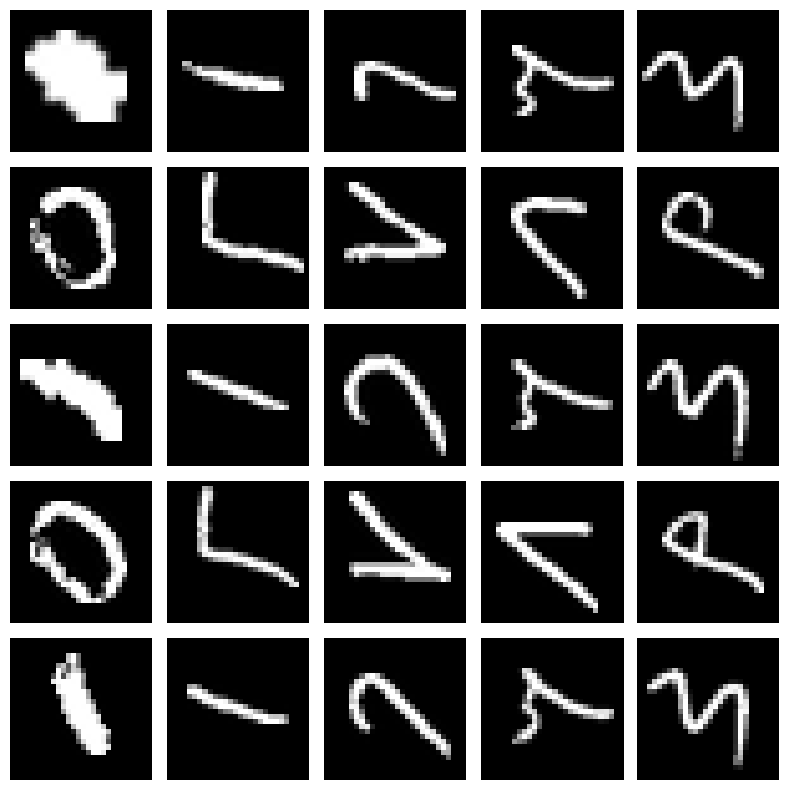

Train value range: 0.0 1.0
Test value range: 0.0 1.0


In [34]:
# Normalize pixel values only when needed
if df_train.to_numpy().max() > 1.0:
    df_train = df_train / 255.0
if df_test.to_numpy().max() > 1.0:
    df_test = df_test / 255.0

# Convert normalized dataframes back to numpy arrays
X_train = df_train.values
X_test = df_test.values

# Reshape flattened vectors to 28x28 grayscale images
X_train = X_train.reshape(-1, 28, 28)
X_test = X_test.reshape(-1, 28, 28)

# Plot the first 25 training images in a 5x5 grid
plt.figure(figsize=(8, 8))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.axis('off')

plt.tight_layout()
plt.show()

print('Train value range:', float(X_train.min()), float(X_train.max()))
print('Test value range:', float(X_test.min()), float(X_test.max()))

## 1.3 Load the label CSV
Load the label CSV files into dataframes and convert them to numpy arrays using pandas.values. Reshape them into 2d numpy arrays

In [35]:
# Load the label data for training and testing.
train_label = pd.read_csv('csvTrainLabel 60k x 1.csv', header=None)
test_label = pd.read_csv('csvTestLabel 10k x 1.csv', header=None)
print('Train labels shape:', train_label.shape)
print('Test labels shape:', test_label.shape)


# Reshape label data to 2D numpy arrays
y_train = train_label.values.reshape(-1, 1)
y_test = test_label.values.reshape(-1, 1)

print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

Train labels shape: (60000, 1)
Test labels shape: (10000, 1)
y_train shape: (60000, 1)
y_test shape: (10000, 1)


# 2. Modeling
## 2.1 Create a function that generates real sample of data from the training dataset.


In [36]:
# Function to generate real data samples
def realData(batch):
    # Get the training data loaded earlier in the notebook
    X = X_train.astype('float32')

    # Reshaping the input data to include channel
    if X.ndim == 3:
        X = X[:, :, :, np.newaxis]

    # Match generator tanh output range: [-1, 1]
    X = (X * 2.0) - 1.0

    # Generate a random batch of real samples
    imageBatch = X[np.random.randint(0, X.shape[0], size=batch)]
    return imageBatch

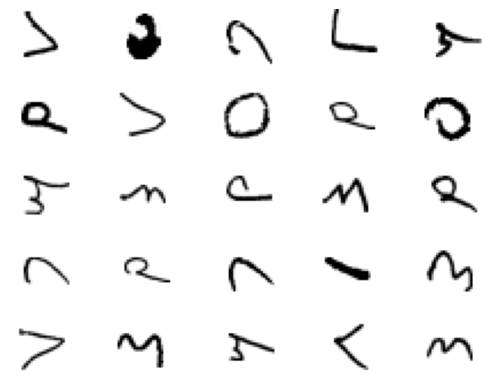

In [37]:
# Generating a batch of  images
arabic_digit = realData(25)

 # Plotting the images

for j in range(5*5):
    pyplot.subplot(5,5,j+1)
    # turn off axis 
    pyplot.axis('off') 
    pyplot.imshow(arabic_digit[j,:,:,0],cmap='gray_r')

## 2.2 Fake data generator
Create a function to generate inputs for the fake data generator function.

In [38]:
# Function to generate inputs for generator function
def fakeInputs(batch,infeats):
    # Generate random noise data with shape (batch,input features)
    x_fake = np.random.uniform(-1,1,size=[batch,infeats])
    return x_fake

## 2.3 compile a generator model
Define and compile a generator model

In [39]:
# Function for the generator model
def genModel(infeats):
    # Defining the Generator model
    Genmodel = Sequential()
    Genmodel.add(Dense(512,input_dim=infeats))
    Genmodel.add(Activation('relu'))
    Genmodel.add(BatchNormalization())
    # second layer of FC => RElu => BN layers
    Genmodel.add(Dense(7*7*64))
    Genmodel.add(Activation('relu'))
    Genmodel.add(BatchNormalization())
    # Upsample to 14 x 14
    Genmodel.add(Reshape((7,7,64)))
    Genmodel.add(Conv2DTranspose(32,kernel_size=(5,5),strides=(2,2),padding='same'))
    Genmodel.add(Activation('relu'))
    Genmodel.add(BatchNormalization(axis = -1))
    # Updample to 28 x 28
    Genmodel.add(Conv2DTranspose(1,kernel_size=(5,5),strides=(2,2),padding='same'))
    Genmodel.add(Activation('tanh'))    
    return Genmodel


In [40]:
Genmodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 512)               51712     
                                                                 
 activation_4 (Activation)   (None, 512)               0         
                                                                 
 batch_normalization_3 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dense_3 (Dense)             (None, 3136)              1608768   
                                                                 
 activation_5 (Activation)   (None, 3136)              0         
                                                                 
 batch_normalization_4 (Batc  (None, 3136)             12544     
 hNormalization)                                      

## 2.4  fake samples generator
Create a function to generate fake samples using the generator model, taking input from the function created in part b.

In [22]:
# Function to create fake samples using the generator model
def fakedataGenerator(Genmodel, batch, infeats):
    # First generate the random inputs to the model
    genInputs = fakeInputs(batch, infeats)
    # Use these inputs inside the generator model to generate fake distribution
    X_fake = Genmodel.predict(genInputs, verbose=0)

    return X_fake

## 2.5 compile a discriminator model
Define and compile a discriminator model

In [23]:
# Define the arguments like batch size and input feature
batch = 128
infeats = 100
Genmodel = genModel(infeats)
Genmodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 512)               51712     
                                                                 
 activation_4 (Activation)   (None, 512)               0         
                                                                 
 batch_normalization_3 (Batc  (None, 512)              2048      
 hNormalization)                                                 
                                                                 
 dense_3 (Dense)             (None, 3136)              1608768   
                                                                 
 activation_5 (Activation)   (None, 3136)              0         
                                                                 
 batch_normalization_4 (Batc  (None, 3136)             12544     
 hNormalization)                                      

In [24]:
# Generating a fake sample and printing the shape
fake = fakedataGenerator(Genmodel,batch,infeats)
fake.shape

(128, 28, 28, 1)

Text(0.5, 0, 'Fake Sample Image')

Text(0.5, 0, 'Fake Sample Image')

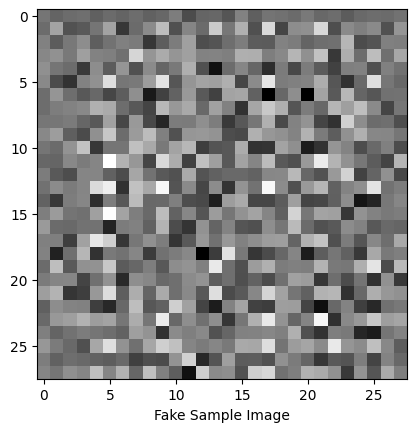

In [25]:
# Plotting the fake sample

plt.imshow(fake[1, :, :, 0], cmap='gray_r')
 
plt.xlabel('Fake Sample Image') 

## 2.6 compile GAN model
Define and compile a GAN model from the generator and discriminator models; be sure to set the discriminator part to be untrainable

In [26]:
# Descriminator model as a function
def discModel():
    Discmodel = Sequential()
    Discmodel.add(Conv2D(32,kernel_size=(5,5),strides=(2,2),padding='same',input_shape=(28,28,1)))    
    Discmodel.add(LeakyReLU(0.2))
    # second layer of convolutions
    Discmodel.add(Conv2D(64, kernel_size=(5,5), strides=(2, 2), padding='same'))   
    Discmodel.add(LeakyReLU(0.2))
    # Fully connected layers
    Discmodel.add(Flatten())
    Discmodel.add(Dense(512))
    Discmodel.add(LeakyReLU(0.2))
    Discmodel.add(Dense(1, activation='sigmoid'))
    Discmodel.compile(loss='binary_crossentropy', optimizer=Adam(lr=0.0002, beta_1=0.5),metrics=['accuracy'])   
    return Discmodel 

In [27]:
# Print the summary of the discriminator model
Discmodel = discModel()
Discmodel.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 32)        832       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 14, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 64)          51264     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 7, 7, 64)          0         
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense_4 (Dense)             (None, 512)               1606144   
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 512)              

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 14, 14, 32)        832       
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 14, 14, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 7, 7, 64)          51264     
                                                                 
 leaky_re_lu_1 (LeakyReLU)   (None, 7, 7, 64)          0         
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense_4 (Dense)             (None, 512)               1606144   
                                                                 
 leaky_re_lu_2 (LeakyReLU)   (None, 512)              

c:\Users\fajayi\AppData\Local\anaconda3\envs\NNDL\lib\site-packages\keras\optimizers\optimizer_v2\adam.py:110: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super(Adam, self).__init__(name, **kwargs)


In [28]:
# Define the combined generator and discriminator model, for updating the generator
def ganModel(Genmodel, Discmodel):
    # Set discriminator model to untrainable inside GAN
    Discmodel.trainable = False
    Ganmodel = Sequential()
    # First add generator, then discriminator
    Ganmodel.add(Genmodel)
    Ganmodel.add(Discmodel)
    # Compile GAN model for updating generator weights
    Ganmodel.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.0002, beta_1=0.5))
    return Ganmodel

In [29]:
# Initialise the gan model
gan_model = ganModel(Genmodel,Discmodel)
# Print summary of the GAN model
gan_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 28, 28, 1)         1727233   
                                                                 
 sequential_2 (Sequential)   (None, 1)                 1658753   
                                                                 
Total params: 3,385,986
Trainable params: 1,719,873
Non-trainable params: 1,666,113
_________________________________________________________________


## 2.7 Training
Train the GAN network using tf.keras.train_on_batch.

In [30]:
# Defining the number of epochs
nEpochs = 5000

In [31]:
# Train the GAN network
for i in range(nEpochs):
    # Generate samples equal to the bath size from the real distribution
    x_real = realData(batch)
    # Generate fake samples using the fake data generator function
    x_fake = fakedataGenerator(Genmodel,batch,infeats)
    # Concatenating the real and fake data 
    X = np.concatenate([x_real,x_fake])
    # Creating the dependent variable and initializing them as '0'
    Y = np.zeros(batch * 2)
    # making the first set equivalent to batch with labels 1
    Y[:batch] = 1
    # train the  discriminator on the real samples
    discLoss = Discmodel.train_on_batch(X, Y)
    # Generate new fake inputs for training the GAN network
    x_gan = fakeInputs(batch*2,infeats)
    # Create labels of the fake examples as 1 to fool the discriminator
    y_gan = np.ones((batch*2, 1))
    # Update the generator model through the discriminator model
    gan_model.train_on_batch(x_gan, y_gan)
    # Print the accuracy measures on the real and fake data for every 10 epochs
    if (i) % 50 == 0:
        # Printing the descriminator loss and accuracy
        x_real_test = realData(10)
        x_fake_test = fakedataGenerator(Genmodel,10,infeats)
        # Concatenating the real and fake data 
        X_test = np.concatenate([x_real_test,x_fake_test])
        # Creating the dependent variable and initializing them as '0'
        Y = np.zeros(20 * 2)
        Y[:10] = 1
        # Predicting probabilities
        preds = Discmodel.predict(X_test)
        print('Discriminator probability:{D}'.format(D=np.mean(preds)))
        # Generate fake samples using the fake data generator function
        x_fake = fakedataGenerator(Genmodel,batch,infeats)
        # Saving the plots
        for j in range(5*5):
            pyplot.subplot(5,5,j+1)
            # turn off axis 
            pyplot.axis('off')
            pyplot.imshow(x_fake[j,:,:,0],cmap='gray_r')                       
        filename = 'handwritten/Gan_Arabic_Handwritten_Training_Plot%03d.png' % (i)
        pyplot.savefig(filename)
        pyplot.close()
            

1/1 [==============================] - 0s 48ms/step
Discriminator probability:0.5608160495758057
1/1 [==============================] - 0s 11ms/step
Discriminator probability:0.5003271102905273
1/1 [==============================] - 0s 11ms/step
Discriminator probability:0.5000494718551636
1/1 [==============================] - 0s 18ms/step
Discriminator probability:0.500117838382721
1/1 [==============================] - 0s 15ms/step
Discriminator probability:0.5001134276390076
1/1 [==============================] - 0s 22ms/step
Discriminator probability:0.5006877183914185
1/1 [==============================] - 0s 15ms/step
Discriminator probability:0.6770516037940979
1/1 [==============================] - 0s 17ms/step
Discriminator probability:0.292822003364563
1/1 [==============================] - 0s 16ms/step
Discriminator probability:0.613098680973053
1/1 [==============================] - 0s 17ms/step
Discriminator probability:0.31188103556632996
1/1 [===========================